##### NOTEBOOK 2 ==> Feature Extraction 

##### Convert the MSRC-v2 image dataset into **numerical descriptors** that capture
##### the global colour distribution of each image. These descriptors will power
##### the visual search system

In [1]:
import sys
import pandas as pd 
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
sns.set(style="whitegrid")

# Add project root to Python path so we can import from src/
project_root = Path("../")
sys.path.append(str(project_root.resolve()))

from src.utils.io_utils import list_images
from src.extractors.color_hist import color_histogram, ColorHistConfig


### Loading Datasets Image Paths

In [2]:
DATA_DIR = Path("../data/MSRC_ObjCategImageDatabase_v2")
OUT_DIR = Path("../data/Descriptors")
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = list_images(DATA_DIR)
print(f"✅ Found {len(paths)} images in dataset.")
print(f"Example image: {paths[0].name}")


✅ Found 1214 images in dataset.
Example image: 10_10_s_GT.bmp


### Defining the Descriptor Configurations into RGB and HSV

In [3]:
colour_spaces = ["RGB", "HSV"]
quantizations = [(4,4,4), (8,8,8), (16,16,16)]

### Calculating and Saving Descriptors 

In [ ]:
for space in colour_spaces:
    for bins in quantizations:
        cfg = ColorHistConfig(space=space, bins=bins, normalize=True)
        descs = {}
        print(f"\n.**.. Extracting {space} histograms with bins {bins} ...")

        for p in tqdm(paths, desc=f"{space}-{bins}"):
            img = cv2.imread(str(p))
            if img is None:
                continue
            descs[p.name] = color_histogram(img, cfg)

        file_name = f"{space}_{bins[0]}x{bins[1]}x{bins[2]}.pkl"
        with open(OUT_DIR / file_name, "wb") as f:
            pickle.dump({"config": cfg, "descriptors": descs}, f)
        print(f"**** Saved {len(descs)} descriptors → {file_name}")



🧩 Extracting RGB histograms with bins (4, 4, 4) ...


RGB-(4, 4, 4):   0%|          | 0/1214 [00:00<?, ?it/s]

RGB-(4, 4, 4): 100%|██████████| 1214/1214 [00:00<00:00, 1541.41it/s]


✅ Saved 1198 descriptors → RGB_4x4x4.pkl

🧩 Extracting RGB histograms with bins (8, 8, 8) ...


RGB-(8, 8, 8): 100%|██████████| 1214/1214 [00:00<00:00, 3182.53it/s]


...

✅ Saved 1198 descriptors → HSV_4x4x4.pkl

🧩 Extracting HSV histograms with bins (8, 8, 8) ...


HSV-(8, 8, 8): 100%|██████████| 1214/1214 [00:00<00:00, 1938.54it/s]


✅ Saved 1198 descriptors → HSV_8x8x8.pkl

🧩 Extracting HSV histograms with bins (16, 16, 16) ...


HSV-(16, 16, 16): 100%|██████████| 1214/1214 [00:00<00:00, 1997.40it/s]

✅ Saved 1198 descriptors → HSV_16x16x16.pkl


### Inspecting One of the Descriptor for an insight 

Vector length: 512
Vector sum (should be 1.0): 1.0


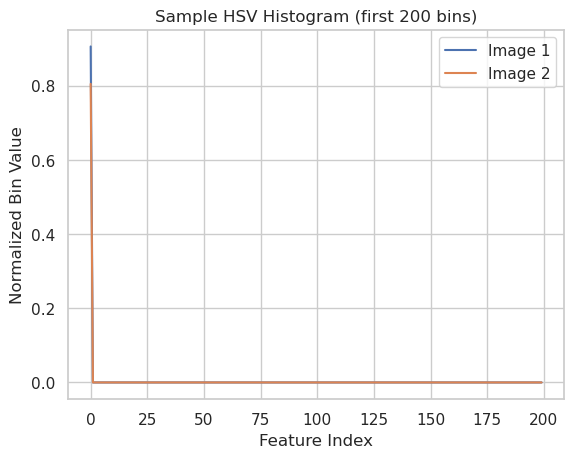

In [5]:
example_file = OUT_DIR / "HSV_8x8x8.pkl"
data = pickle.load(open(example_file, "rb"))
vectors = np.array(list(data["descriptors"].values()))

print("Vector length:", len(vectors[0]))
print("Vector sum (should be 1.0):", round(vectors[0].sum(), 4))

plt.plot(vectors[0][:200], label="Image 1")
plt.plot(vectors[1][:200], label="Image 2")
plt.title("Sample HSV Histogram (first 200 bins)")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Bin Value")
plt.legend()
plt.show()



### Comparing Vector Dimensionality


In [6]:
import pandas as pd

summary = []
for space in colour_spaces:
    for bins in quantizations:
        f = OUT_DIR / f"{space}_{bins[0]}x{bins[1]}x{bins[2]}.pkl"
        if not f.exists(): continue
        data = pickle.load(open(f, "rb"))
        sample = next(iter(data["descriptors"].values()))
        summary.append({
            "Colour Space": space,
            "Bins": bins,
            "Vector Length": len(sample)
        })

df_summary = pd.DataFrame(summary)
display(df_summary)

report_dir = Path("../report")
report_dir.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(report_dir / "descriptor_summary.csv", index=False)


,Colour Space,Bins,Vector Length
0,RGB,"(4, 4, 4)",64
1,RGB,"(8, 8, 8)",512
2,RGB,"(16, 16, 16)",4096
3,HSV,"(4, 4, 4)",64
4,HSV,"(8, 8, 8)",512
5,HSV,"(16, 16, 16)",4096



###  Efficiency Check 


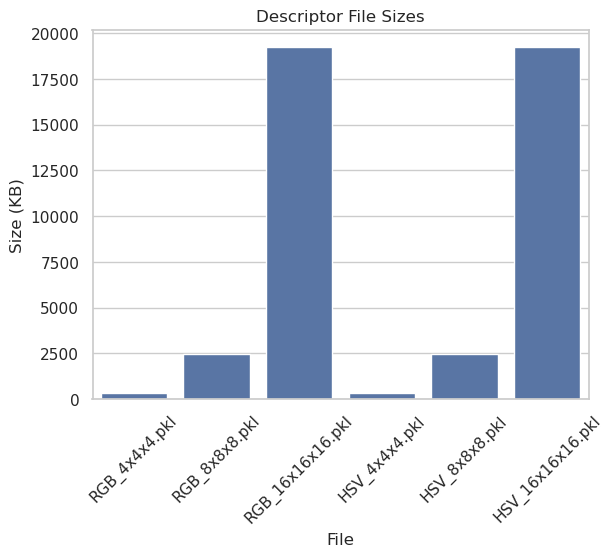

In [7]:
import os

records = []
for f in OUT_DIR.glob("*.pkl"):
    size_kb = os.path.getsize(f) / 1024
    records.append({"File": f.name, "Size (KB)": round(size_kb, 2)})

df_sizes = pd.DataFrame(records)
sns.barplot(x="File", y="Size (KB)", data=df_sizes)
plt.xticks(rotation=45)
plt.title("Descriptor File Sizes")
plt.show()


###  Descriptor Extraction Summary

In [ ]:
import os, time
from datetime import datetime

start_time = locals().get("_notebook_start", time.time())
OUT_DIR = Path("../data/Descriptors")

records = []
for f in OUT_DIR.glob("*.pkl"):
    size_kb = round(os.path.getsize(f) / 1024, 2)
    records.append({
        "File": f.name,
        "Size (KB)": size_kb,
        "Modified": datetime.fromtimestamp(f.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
    })

df_files = pd.DataFrame(records).sort_values("File")
display(df_files)

REPORT_DIR = Path("../report")
log_path = REPORT_DIR / "feature_extraction_log.txt"

with open(log_path, "w") as f:
    f.write(f"Feature Extraction completed: {datetime.now()}\n")
    f.write(f"Total descriptor files: {len(records)}\n\n")
    for rec in records:
        f.write(f"{rec['File']:25}  {rec['Size (KB)']:>8} KB\n")

elapsed = time.time() - start_time
print(f"***--- Feature extraction finished in {elapsed/60:.1f} minutes.")
print(f"Log saved to {log_path}")


,File,Size (KB),Modified
5,HSV_16x16x16.pkl,19227.95,2025-11-10 22:08
3,HSV_4x4x4.pkl,355.69,2025-11-10 22:08
4,HSV_8x8x8.pkl,2453.64,2025-11-10 22:08
2,RGB_16x16x16.pkl,19227.95,2025-11-10 22:08
0,RGB_4x4x4.pkl,355.69,2025-11-10 22:08
1,RGB_8x8x8.pkl,2453.64,2025-11-10 22:08


✅ Feature extraction finished in 0.0 minutes.
Log saved to ../report/feature_extraction_log.txt
